# Figure 7: Twist vs No-Twist Dorsal-Ventral Analysis

## DNA FISH Distance Analysis Along the Dorsal-Ventral Axis

**Reference:** Le MT, McGehee J, Dunipace L, Rumph D, Stathopoulos A. (2026) *Inferring chromatin architecture at a single locus through probabilistic in situ DNA localization.* Nature Communications.  
DOI: [10.1038/s41467-026-68460-x](https://doi.org/10.1038/s41467-026-68460-x)

---

### Scientific Background

Figure 7 examines chromatin architecture along the **dorsal-ventral (D-V) axis** of the embryo by comparing regions where the transcription factor **Twist** is expressed versus regions where it is not.

**Twist** is a key transcription factor in the Dorsal signaling pathway:
- Expressed in the **ventral** region of the embryo (where Dorsal nuclear levels are highest)
- Activates mesoderm-specific genes
- Its expression domain marks regions of active transcription at the *brk* locus

### Regions Analyzed

The embryo is divided into four quadrants based on D-V and A-P position:

| Region | D-V | A-P | Twist Expression |
|--------|-----|-----|------------------|
| **Region 1** | Dorsal | Anterior | No Twist |
| **Region 2** | Ventral | Anterior | Twist |
| **Region 3** | Dorsal | Posterior | No Twist |
| **Region 4** | Ventral | Posterior | Twist |

### Comparisons Performed

1. **Twist vs No-Twist** (overall D-V comparison)
2. **A/P within Twist region** (ventral anterior vs ventral posterior)
3. **A/P within No-Twist region** (dorsal anterior vs dorsal posterior)
4. **Pooled Anterior vs Pooled Posterior** (combined D-V regions)

### Three DNA Elements Measured

| Element | Color | Description |
|---------|-------|-------------|
| **E1** | Blue (647nm) | Enhancer 1 (5' enhancer) |
| **PPE** | Green (561nm) | Primary Promoter Element |
| **E2** | Red (488nm) | Enhancer 2 (3' enhancer) |

---

### Figure 7 Panel Map

| Panel | Content | Section |
|-------|---------|--------|
| **7A-B** | Twist vs No-Twist PDFs and KS tests | Section III |
| **7C-D** | A/P comparisons within D-V regions | Section IV-V |
| **7E** | Pooled A/P comparisons | Section VI |
| **7F** | Joint distribution contour plots | Section VII |

---

## Table of Contents

| Section | Description |
|---------|-------------|
| **I** | [Configuration and Setup](#section-i) - Paths, imports, helper functions |
| **II** | [Load Data](#section-ii) - Extract distances for all regions |
| **III** | [Twist vs No-Twist](#section-iii) - D-V axis comparison (Figure 7A-B) |
| **IV** | [A/P Within Twist Region](#section-iv) - Anterior vs Posterior in ventral domain |
| **V** | [A/P Within No-Twist Region](#section-v) - Anterior vs Posterior in dorsal domain |
| **VI** | [Pooled A/P Comparison](#section-vi) - Combined anterior vs posterior (Figure 7E) |
| **VII** | [Contour Analysis](#section-vii) - Joint distribution contours (Figure 7F) |
| **VIII** | [Cross-Region Heatmaps](#section-viii) - All pairwise p-value heatmaps |
| **IX** | [Summary](#section-ix) - Key findings and output files |

---

<a id="section-i"></a>
# Section I: Configuration and Setup

This section:
1. Defines the data directory path
2. Imports required Python libraries
3. Creates helper functions for data extraction, filtering, visualization, and statistics

### Update Data Path

Change `DATA_ROOT` below to match where your twist/no-twist data is stored.

In [1]:
# =============================================================================
# DATA PATH CONFIGURATION
# =============================================================================
DATA_ROOT = '/Volumes/stathopouloslab/nina/Spots_troubleshooting/09_29_25_YW_twi/'
ROOT_TWI = DATA_ROOT

# Stage/region folder names within DATA_ROOT
STAGES_DV = ['twi', 'no_twi']                     # D-V comparison
STAGES_TWI_AP = ['twi_A', 'twi_C']               # A/P within twist region
STAGES_NO_TWI_AP = ['no_twi_A', 'no_twi_C']     # A/P within no-twist region
STAGES_AP_ALL = ['Anterior_only', 'Posterior_only']  # Pooled A/P

# Labels for plots
DV_LABELS = ['Twist', 'No Twist']
AP_LABELS = ['Anterior', 'Posterior']

# Color palette aligned to published Figure 7
COLOR_TWIST = '#9E9E9E'     # gray (inactive / twist)
COLOR_NO_TWIST = '#5DA5DA'  # blue (active / no-twist)
COLOR_ANTERIOR = '#B39DDB'  # purple
COLOR_POSTERIOR = '#E15759' # red

DV_COLORS = [COLOR_TWIST, COLOR_NO_TWIST]
AP_COLORS = [COLOR_ANTERIOR, COLOR_POSTERIOR]
POOL_COLORS = [COLOR_ANTERIOR, COLOR_POSTERIOR]

# Imaging resolution limits (micrometers)
RES_XY = 0.12
RES_Z = 0.35
RES_SQUARED = [RES_XY**2, RES_XY**2, RES_Z**2]

print(f"Data root: {DATA_ROOT}")
print(f"D-V regions: {STAGES_DV}")
print(f"Twist A/P: {STAGES_TWI_AP}")
print(f"No-Twist A/P: {STAGES_NO_TWI_AP}")
print(f"Pooled A/P: {STAGES_AP_ALL}")


Data root: /Volumes/stathopouloslab/nina/Spots_troubleshooting/09_29_25_YW_twi/
D-V regions: ['twi', 'no_twi']
Twist A/P: ['twi_A', 'twi_C']
No-Twist A/P: ['no_twi_A', 'no_twi_C']
Pooled A/P: ['Anterior_only', 'Posterior_only']


### Import Required Libraries

In [2]:
# =============================================================================
# LIBRARY IMPORTS
# =============================================================================
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Core data handling
import numpy as np
import pandas as pd

# Statistical analysis
from scipy.stats import gaussian_kde, ks_2samp
from scipy.interpolate import NearestNDInterpolator
from statsmodels.stats.multitest import multipletests

# Visualization - Matplotlib/Seaborn
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns

# Visualization - Bokeh (interactive plots)
import bokeh.io
import bokeh.layouts as bl
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Range1d, Legend, LegendItem
import iqplot

# Enable inline Bokeh output
bokeh.io.output_notebook()

print("All libraries imported successfully!")

Loading BokehJS ...

All libraries imported successfully!


In [3]:
# Color palette aligned to published Figure 7
COLOR_TWIST = '#9E9E9E'     # gray (inactive / twist)
COLOR_NO_TWIST = '#5DA5DA'  # blue (active / no-twist)
COLOR_ANTERIOR = '#B39DDB'  # purple
COLOR_POSTERIOR = '#E15759' # red


### Data Extraction Function

Reads CSV files from each region folder and extracts the three pairwise distances:
- **E1-PPE**: Distance between Enhancer 1 and Promoter
- **E2-PPE**: Distance between Enhancer 2 and Promoter
- **E1-E2**: Distance between the two enhancers

In [4]:
def extract_distances_from_folders(base_path, stages):
    """
    Extract pairwise distances (E1-PPE, E2-PPE, E1-E2) from CSV files.

    Parameters
    ----------
    base_path : str
        Path to the directory containing region subfolders
    stages : list
        List of folder names to process (e.g., ['twi', 'no_twi'])

    Returns
    -------
    dict
        Dictionary with keys like 'twi_E1-PPE' containing DataFrames

    Notes
    -----
    CSV column mapping (from find_spots GUI):
    - leftDist = E2-PPE (488nm channel was in Left box)
    - rightDist = E1-PPE (647nm channel was in Right box)
    - leftRightDist = E1-E2 (distance between flanking spots)
    """
    result = {}

    for stage in stages:
        folder_path = os.path.join(base_path, stage)
        csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

        if not csv_files:
            print(f"  No CSV files found in {folder_path}")
            continue

        dfs = [pd.read_csv(f) for f in csv_files]
        stage_df = pd.concat(dfs, axis=0, ignore_index=True)

        coord_cols = ['Xleft', 'Yleft', 'Zleft',
                      'Xmiddle', 'Ymiddle', 'Zmiddle',
                      'Xright', 'Yright', 'Zright']

        # E2-PPE (leftDist)
        if 'leftDist' in stage_df.columns:
            e2_ppe = stage_df.dropna(subset=['leftDist'])[coord_cols + ['leftDist']].copy()
            e2_ppe = e2_ppe.rename(columns={'leftDist': 'E2-PPE distance (um)'})
            result[f'{stage}_E2-PPE'] = e2_ppe

        # E1-PPE (rightDist)
        if 'rightDist' in stage_df.columns:
            e1_ppe = stage_df.dropna(subset=['rightDist'])[coord_cols + ['rightDist']].copy()
            e1_ppe = e1_ppe.rename(columns={'rightDist': 'E1-PPE distance (um)'})
            result[f'{stage}_E1-PPE'] = e1_ppe

        # E1-E2 (leftRightDist)
        if 'leftRightDist' in stage_df.columns:
            e1_e2 = stage_df.dropna(subset=['leftRightDist'])[coord_cols + ['leftRightDist']].copy()
            e1_e2 = e1_e2.rename(columns={'leftRightDist': 'E1-E2 distance (um)'})
            result[f'{stage}_E1-E2'] = e1_e2

        n_e1ppe = len(result.get(f'{stage}_E1-PPE', []))
        n_e2ppe = len(result.get(f'{stage}_E2-PPE', []))
        n_e1e2 = len(result.get(f'{stage}_E1-E2', []))
        print(f"  {stage}: E1-PPE={n_e1ppe}, E2-PPE={n_e2ppe}, E1-E2={n_e1e2} measurements")

    return result

### Resolution Filtering Function

Spots closer than the microscope resolution limit cannot be reliably distinguished.

**Resolution limits:** XY: 0.12 um | Z: 0.35 um

In [5]:
def below_resolution_limit(p1, p2, res_sq):
    """
    Check if two 3D points are closer than the resolution limit.
    Uses ellipsoidal distance accounting for different XY vs Z resolution.
    """
    try:
        return (
            ((p1[0] - p2[0])**2) / res_sq[0] +
            ((p1[1] - p2[1])**2) / res_sq[1] +
            ((p1[2] - p2[2])**2) / res_sq[2]
        ) < 1.0
    except Exception:
        return False


def apply_resolution_filtering(distance_data, res_sq=None):
    """
    Set sub-resolution distances to 0.0 in-place.

    Parameters
    ----------
    distance_data : dict
        Dictionary of DataFrames from extract_distances_from_folders()
    res_sq : list
        Squared resolution limits [X^2, Y^2, Z^2]
    """
    if res_sq is None:
        res_sq = RES_SQUARED

    filtered_count = 0

    for key, df in distance_data.items():
        if 'E2-PPE' in key:
            p1_cols, p2_cols = ['Xleft', 'Yleft', 'Zleft'], ['Xmiddle', 'Ymiddle', 'Zmiddle']
            dist_col = 'E2-PPE distance (um)'
        elif 'E1-PPE' in key:
            p1_cols, p2_cols = ['Xright', 'Yright', 'Zright'], ['Xmiddle', 'Ymiddle', 'Zmiddle']
            dist_col = 'E1-PPE distance (um)'
        elif 'E1-E2' in key:
            p1_cols, p2_cols = ['Xleft', 'Yleft', 'Zleft'], ['Xright', 'Yright', 'Zright']
            dist_col = 'E1-E2 distance (um)'
        else:
            continue

        for idx, row in df.iterrows():
            if row[p1_cols + p2_cols].notna().all():
                p1 = row[p1_cols].tolist()
                p2 = row[p2_cols].tolist()
                if below_resolution_limit(p1, p2, res_sq):
                    df.at[idx, dist_col] = 0.0
                    filtered_count += 1

    print(f"  Resolution filtering: {filtered_count} measurements set to 0")
    return distance_data

### PDF Comparison Plot Function

Generates two visualizations for comparing two conditions:
1. **Strip-box plot** (left): Individual data points with swarm layout
2. **PDF plot** (right): Smooth probability density curves with 95% bootstrap confidence intervals

In [6]:
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, Legend, LegendItem, HoverTool, Range1d
import bokeh.io
import numpy as np
from scipy.stats import gaussian_kde, ks_2samp

bokeh.io.output_notebook()  # inline display in Jupyter

def generate_pdf_comparison_mutant(
    sample1_dataframe, sample2_dataframe,
    distance_column, title_prefix,
    sample1_name, sample1_color,
    sample2_name, sample2_color,
    n_bootstraps=1000
):
    """
    Generate a PDF comparison plot for 2 samples with KDE + 95% CI shading (bootstrapped),
    legend entries that include sample sizes and medians, and a KS test p-value printed to stdout.
    """

    # ---------- helpers ----------
    def preprocess_data(series):
        """Drop NaNs and add small jitter if there are very few unique values."""
        data = series.dropna().to_numpy()
        if data.size == 0:
            raise ValueError(f"No data after dropping NaNs in column '{distance_column}'.")
        if np.unique(data).size < 5:
            data = data + np.random.normal(0, 1e-3, size=data.shape)  # small noise
        return data

    def kde_and_bootstrap_ci(data, x_vals, n_boot=1000):
        """Compute KDE and 95% CI via bootstrapping over the KDE."""
        base_kde = gaussian_kde(data)
        y = base_kde(x_vals)

        boot = np.empty((n_boot, x_vals.size), dtype=float)
        n = len(data)
        for b in range(n_boot):
            bs = np.random.choice(data, size=n, replace=True)
            boot[b] = gaussian_kde(bs)(x_vals)

        ci_lower = np.percentile(boot, 2.5, axis=0)
        ci_upper = np.percentile(boot, 97.5, axis=0)
        return y, ci_lower, ci_upper

    # ---------- data prep ----------
    s1 = preprocess_data(sample1_dataframe[distance_column])
    s2 = preprocess_data(sample2_dataframe[distance_column])

    # Common x-grid spanning both samples
    xmin = min(s1.min(), s2.min())
    xmax = max(s1.max(), s2.max())
    pad = 0.02 * (xmax - xmin if xmax > xmin else 1.0)
    x_vals = np.linspace(xmin - pad, xmax + pad, 1200)

    # ---------- compute KDEs + bootstrap CIs ----------
    y1, ci1_lo, ci1_hi = kde_and_bootstrap_ci(s1, x_vals, n_bootstraps)
    y2, ci2_lo, ci2_hi = kde_and_bootstrap_ci(s2, x_vals, n_bootstraps)

    # Store results
    phenotypes = [
        {"label": "sample_1", "name": sample1_name, "color": sample1_color,
         "data": s1, "y": y1, "ci_lo": ci1_lo, "ci_hi": ci1_hi},
        {"label": "sample_2", "name": sample2_name, "color": sample2_color,
         "data": s2, "y": y2, "ci_lo": ci2_lo, "ci_hi": ci2_hi},
    ]

    pdf_peaks = {}
    kde_results = {}

    # ---------- figure ----------
    pdf_plot = figure(
        title=f"{title_prefix} - PDF of {distance_column}",
        x_axis_label=distance_column,
        y_axis_label="Probability Density",
        tools="pan,wheel_zoom,box_zoom,reset",
        height=500, width=1000
    )

    # styling
    pdf_plot.title.text_font_size = "13pt"
    pdf_plot.title.align = "center"
    pdf_plot.axis.axis_label_text_font_size = "25pt"
    pdf_plot.axis.axis_label_text_font_style = "bold"
    pdf_plot.axis.major_label_text_font_size = "18pt"
    pdf_plot.axis.major_label_text_font_style = "bold"
    pdf_plot.axis.axis_line_width = 2
    pdf_plot.axis.axis_line_color = "black"
    pdf_plot.axis.major_tick_line_width = 3
    pdf_plot.axis.major_tick_line_color = "black"
    pdf_plot.axis.minor_tick_line_width = 2
    pdf_plot.axis.minor_tick_line_color = "black"
    pdf_plot.title.standoff = 20
    pdf_plot.x_range = Range1d(start=-0.1, end=2)
    pdf_plot.y_range = Range1d(start=0, end=2.2)
    pdf_plot.xgrid.visible = False
    pdf_plot.ygrid.visible = False

    legend_items = []
    hover_tools = []

    # ---------- add both phenotypes ----------
    for p in phenotypes:
        # Peak location
        peak_x = x_vals[np.argmax(p["y"])]
        pdf_peaks[f"PDF_{p['label'].replace(' ', '_')}"] = peak_x
        kde_results[p["label"]] = {"x": x_vals, "y": p["y"]}

        n_points = len(p["data"])
        median_val = float(np.median(p["data"]))
        med_str = f"{median_val:.3f}"

        source = ColumnDataSource(data=dict(
            x=x_vals, y=p["y"], ci_lower=p["ci_lo"], ci_upper=p["ci_hi"]
        ))

        line = pdf_plot.line('x', 'y', source=source, line_width=3, color=p["color"], name=p["name"])
        area = pdf_plot.varea(x='x', y1='ci_lower', y2='ci_upper', source=source,
                              fill_alpha=0.25, fill_color=p["color"])

        legend_items.append(
            LegendItem(
                label=f"{p['name']} (n={n_points:,}, median={med_str})",
                renderers=[line, area]
            )
        )

        hover = HoverTool(
            renderers=[line],
            tooltips=[("x", "@x{0.000}"), ("density", "@y{0.000}"), ("CI", "(@ci_lower{0.000}, @ci_upper{0.000})")]
        )
        hover_tools.append(hover)

    # Add legend (outside, right) and hovers
    legend = Legend(items=legend_items, location="center")
    legend.label_text_font_size = "10pt"
    pdf_plot.add_layout(legend, 'right')
    pdf_plot.legend.click_policy = "hide"
    for h in hover_tools:
        pdf_plot.add_tools(h)

    # KS test
    ks_pval = ks_2samp(s1, s2).pvalue
    print(f"K-S Test ({sample1_name} vs {sample2_name}): {ks_pval:.10f}")

    bokeh.io.show(pdf_plot)

    return pdf_peaks, kde_results


import numpy as np
import pandas as pd
import iqplot

def plot_swarm_box(dataframes, stages_labels, distance_column, title, x_axis_label, palette=None):
    """
    Make a strip+box (swarm) plot like your WT plots.
    dataframes: list of DataFrames, one per stage
    stages_labels: list of stage names (same length as dataframes)
    distance_column: column to plot (e.g., "E1-PPE distance (um)")
    """
    arrays = [df[distance_column].to_numpy() for df in dataframes]

    df_combined = pd.DataFrame({
        distance_column: np.concatenate(arrays),
        "stages": np.concatenate([[stages_labels[i]] * len(arr) for i, arr in enumerate(arrays)])
    })

    if palette is None:
        palette = ['red','#FF00FF','#3F7FFF','#00008B']

    p = iqplot.stripbox(
        df_combined,
        q=distance_column,
        cats="stages",
        title=title,
        x_axis_label=x_axis_label,
        y_axis_label="Developmental Stages",
        frame_height=650,
        spread='swarm',
        palette=palette
    )
    bokeh.io.show(p)
    return p


Loading BokehJS ...

### KS Test Function (with FDR Correction)

Performs Kolmogorov-Smirnov tests between all pairs of conditions with Benjamini-Hochberg FDR correction.

In [7]:
def perform_ks_tests(dataframes, labels, distance_column, alpha=0.05):
    """
    Perform KS tests between all pairs of conditions with FDR correction.

    Parameters
    ----------
    dataframes : list
        List of DataFrames containing distance data
    labels : list
        Labels for each condition
    distance_column : str
        Column name containing distance values
    alpha : float
        FDR threshold (default: 0.05)

    Returns
    -------
    DataFrame
        Results table with D-statistic, p-values, and significance
    """
    results = []
    p_values = []

    for i in range(len(dataframes)):
        for j in range(i + 1, len(dataframes)):
            data1 = dataframes[i][distance_column].dropna()
            data2 = dataframes[j][distance_column].dropna()
            D_stat, p_val = ks_2samp(data1, data2)
            results.append([f"{labels[i]} vs {labels[j]}", D_stat, p_val])
            p_values.append(p_val)

    p_values = np.array(p_values)
    corrected_p = multipletests(p_values, method='fdr_bh')[1]

    # Benjamini-Hochberg ranking
    sorted_idx = np.argsort(p_values)
    num_tests = len(p_values)
    fdr_sig = np.full(num_tests, 'No')
    fdr_thresh = np.zeros(num_tests)
    ranks = np.zeros(num_tests)

    for rank, idx in enumerate(sorted_idx, start=1):
        threshold = (rank / num_tests) * alpha
        fdr_thresh[idx] = threshold
        ranks[idx] = rank
        if p_values[idx] <= threshold:
            fdr_sig[idx] = 'Yes'

    for idx, (comp, D_stat, p_val) in enumerate(results):
        corr_sig = 'Yes' if corrected_p[idx] < alpha else 'No'
        results[idx] = [
            comp, D_stat, p_val, corrected_p[idx], corr_sig,
            fdr_thresh[idx], ranks[idx], fdr_sig[idx]
        ]

    return pd.DataFrame(results, columns=[
        'Comparison', 'D Statistic', 'P-value', 'Corrected P-value',
        'Corrected Sig.', 'FDR Threshold', 'Rank', 'FDR Sig.'
    ])

### P-value Heatmap Function

Creates a heatmap of KS test p-values.

**Color scheme:**
- Bright colors (magma): p < 0.05 (significant)
- Dark/black: p > 0.1 (not significant)
- Hatched diagonal: Self-comparisons (p = 1)

In [8]:
def generate_pvalue_heatmap(dataframes_1, dataframes_2, labels_1, labels_2,
                            distance_column, title="P-value Heatmap",
                            x_axis_label="Group 1", y_axis_label="Group 2"):
    """
    Generate a heatmap of KS test p-values between two groups.

    Parameters
    ----------
    dataframes_1 : list
        First group of DataFrames (rows)
    dataframes_2 : list
        Second group of DataFrames (columns)
    labels_1 : list
        Labels for rows
    labels_2 : list
        Labels for columns
    distance_column : str
        Column containing distance values
    title : str
        Plot title
    """
    # Compute p-value matrix
    p_matrix = np.zeros((len(labels_1), len(labels_2)))
    for i in range(len(labels_1)):
        for j in range(len(labels_2)):
            _, p_val = ks_2samp(
                dataframes_1[i][distance_column].dropna(),
                dataframes_2[j][distance_column].dropna()
            )
            p_matrix[i, j] = p_val

    p_df = pd.DataFrame(p_matrix, index=labels_1, columns=labels_2)

    # Custom colormap
    levels = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.1, 1.0]
    cmap = plt.get_cmap('magma_r', len(levels) - 1)
    norm = BoundaryNorm(levels, ncolors=len(levels) - 1, clip=True)

    fig, ax = plt.subplots(figsize=(8, 6))

    heatmap = sns.heatmap(
        p_df, annot=True, fmt='.3f', cmap=cmap, norm=norm,
        linewidths=1.0, cbar=True, linecolor='#808080',
        annot_kws={'fontsize': 11}
    )

    # Hatching for self-comparisons
    for i in range(p_df.shape[0]):
        for j in range(p_df.shape[1]):
            if p_df.iloc[i, j] == 1:
                rect = patches.Rectangle(
                    (j, i), 1, 1, linewidth=2, edgecolor='#505050',
                    linestyle='dashed', fill=False, hatch='////'
                )
                ax.add_patch(rect)

    for spine in heatmap.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label('p-value', fontsize=14, fontweight='bold')

    plt.title(f"{title}\n({distance_column})", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel(x_axis_label, fontsize=12, fontweight='bold', labelpad=15)
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    plt.ylabel(y_axis_label, fontsize=12, fontweight='bold', labelpad=15)
    plt.xticks(rotation=45, fontsize=12, ha='right')
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.show()

### Contour Analysis Functions

These functions compute and plot 2D joint probability distributions of PPE position relative to E1 and E2.

In [9]:
# =============================================================================
# CONTOUR ANALYSIS FUNCTIONS
# =============================================================================
# Includes helper functions for E1-E2 marginal PDF strips below contours.
# These match the functions used in Figure3-6_distances_cleaned.ipynb.

from scipy.interpolate import NearestNDInterpolator
from scipy.stats import gaussian_kde
from matplotlib.cm import ScalarMappable
from matplotlib import cm


def compute_triangle_vertices_from_PDF(d1_arr, d2_arr, p_d1_arr, p_d2_arr, d3):
    """
    Compute triangle vertex coordinates from distance distributions.

    IMPORTANT: d1 = E2-PPE, d2 = E1-PPE (to match published figures).
    """
    D1, D2 = np.meshgrid(d1_arr, d2_arr, indexing='ij')
    P1, P2 = np.meshgrid(p_d1_arr, p_d2_arr, indexing='ij')
    p = P1 * P2

    valid = (D1 + D2 >= d3) & (D1 + d3 >= D2) & (D2 + d3 >= D1)
    x_C = np.where(valid, (d3**2 + D2**2 - D1**2) / (2 * d3), np.nan)
    y_C = np.where(valid, np.sqrt(np.maximum(D2**2 - x_C**2, 0)), np.nan)

    return x_C, y_C, np.where(valid, p, np.nan)


def compute_weighted_Z(d1_arr, d2_arr, p_d1_arr, p_d2_arr,
                       d3_arr, p_d3_arr, xi, yi,
                       num_samples=50, subsample_stride=3):
    """Compute weighted 2D PDF surface by integrating over E1-E2 distances."""
    X_grid, Y_grid = np.meshgrid(xi, yi)

    indices = np.linspace(0, len(d3_arr) - 1, num_samples, dtype=int)
    d3_sampled = d3_arr[indices]
    p_d3_sampled = p_d3_arr[indices]
    p_d3_sampled /= np.sum(p_d3_sampled)

    bin_edges = np.concatenate([
        [d3_sampled[0] - (d3_sampled[1] - d3_sampled[0]) / 2],
        (d3_sampled[:-1] + d3_sampled[1:]) / 2,
        [d3_sampled[-1] + (d3_sampled[-1] - d3_sampled[-2]) / 2]
    ])
    weights = p_d3_sampled * np.diff(bin_edges)
    weights /= np.sum(weights)

    d1_sub, p_d1_sub = d1_arr[::subsample_stride], p_d1_arr[::subsample_stride]
    d2_sub, p_d2_sub = d2_arr[::subsample_stride], p_d2_arr[::subsample_stride]

    Z_weighted = np.zeros_like(X_grid)
    total_weight = 0
    dx, dy = xi[1] - xi[0], yi[1] - yi[0]

    for d3, w in zip(d3_sampled, weights):
        x_coords, y_coords, p_vals = compute_triangle_vertices_from_PDF(
            d1_sub, d2_sub, p_d1_sub, p_d2_sub, d3)
        valid = ~np.isnan(x_coords) & ~np.isnan(y_coords) & ~np.isnan(p_vals)
        if np.count_nonzero(valid) == 0:
            continue
        interpolator = NearestNDInterpolator(
            list(zip(x_coords[valid], y_coords[valid])), p_vals[valid])
        Z_interp = interpolator(X_grid, Y_grid)
        area = np.sum(Z_interp) * dx * dy
        if area > 0:
            Z_interp /= area
            Z_weighted += Z_interp * w
        total_weight += w

    if total_weight > 0:
        Z_weighted /= total_weight

    print(f"Surface integral: {np.sum(Z_weighted) * dx * dy:.4f}")
    return Z_weighted, X_grid, Y_grid


def compute_kde(data, dist_col):
    """Compute normalized KDE for a distance column."""
    arr = data[dist_col].dropna().to_numpy()
    kde = gaussian_kde(arr)
    x = np.linspace(arr.min(), arr.max(), 500)
    y = kde(x)
    y /= np.trapezoid(y, x)
    return {'x': x, 'y': y}


# ---- Helper for E1-E2 strip ----
def _span_to_fig(ax, x_left, x_right):
    """Convert axis x-coordinates to figure-fraction coordinates."""
    x0, x1 = ax.get_xlim()
    bbox = ax.get_position()
    u0 = (x_left - x0) / (x1 - x0)
    u1 = (x_right - x0) / (x1 - x0)
    left_u, right_u = min(u0, u1), max(u0, u1)
    left_fig = bbox.x0 + left_u * bbox.width
    width_fig = (right_u - left_u) * bbox.width
    return left_fig, width_fig


def _draw_kde_strip_from_e1_positions(
    fig, ax_main, *, E1, E2, d, p,
    strip_bottom, strip_h, cb_bottom, cb_h,
    cmap, label, show_xlabel=False,
    unit_max=False, pdf_vmin=0.0, pdf_vmax=1.6
):
    """Draw a horizontal KDE strip below the main contour axis."""
    d = np.asarray(d, float); p = np.asarray(p, float)
    order = np.argsort(d); d, p = d[order], p[order]

    E1x, E2x = float(E1[0]), float(E2[0])
    xlim0, xlim1 = ax_main.get_xlim()
    sign = 1.0 if E2x >= E1x else -1.0
    d_cap = (xlim1 - E1x) if sign > 0 else (E1x - xlim0)
    d_cap = max(0.0, float(d_cap))
    if d_cap == 0:
        return None, None

    keep = (d >= 0) & (d <= d_cap)
    if not np.any(keep):
        d_vis = np.array([0.0, d_cap])
        p_vis = np.interp(d_vis, d, p, left=p[0] if d.size else 0, right=p[-1] if d.size else 0)
    else:
        d_vis = d[keep]; p_vis = p[keep]
        if d_vis[0] > 0:
            p0 = np.interp(0.0, d, p); d_vis = np.insert(d_vis, 0, 0.0); p_vis = np.insert(p_vis, 0, p0)
        if d_vis[-1] < d_cap:
            pE = np.interp(d_cap, d, p); d_vis = np.append(d_vis, d_cap); p_vis = np.append(p_vis, pE)

    if unit_max:
        vmin, vmax = 0.0, 1.0
        p_draw = p_vis / max(np.nanmax(p_vis), 1e-12)
        cb_norm = plt.Normalize(vmin, vmax)
        cb_title = f"{label} (unit-max)"
        cb_ticks = [0, 0.25, 0.5, 0.75, 1.0]
    else:
        vmin, vmax = pdf_vmin, pdf_vmax
        p_draw = p_vis
        cb_norm = plt.Normalize(vmin, vmax)
        cb_title = f"{label}"
        cb_ticks = np.linspace(vmin, vmax, 5)

    img = p_draw[np.newaxis, :]
    x_start, x_end = E1x, E1x + sign * d_cap
    left_fig, width_fig = _span_to_fig(ax_main, x_start, x_end)

    ax_strip = fig.add_axes([left_fig, strip_bottom, width_fig, strip_h])
    ax_strip.imshow(img, aspect='auto', origin='lower', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=[0, d_cap, 0, 1])
    ax_strip.set_yticks([]); ax_strip.set_xlim(0, d_cap)
    if show_xlabel:
        ax_strip.set_xlabel("distance from E1 (um)")
    else:
        ax_strip.set_xticklabels([]); ax_strip.set_xlabel("")

    sm = ScalarMappable(cmap=cmap, norm=cb_norm); sm.set_array([])
    ax_cb = fig.add_axes([left_fig, cb_bottom, width_fig, cb_h])
    cb = fig.colorbar(sm, cax=ax_cb, orientation="horizontal")
    cb.set_ticks(cb_ticks); cb.ax.set_title(cb_title, fontsize=10, pad=10, loc="left")
    cb.ax.tick_params(labelsize=9, pad=2)
    return ax_strip, cb


def plot_contour_stage(d1_arr, d2_arr, p_d1_arr, p_d2_arr,
                       d3_arr, p_d3_arr, title,
                       show_legend=True, num_samples=50, vmin=None, vmax=None):
    """
    Plot 2D PDF contour with E1-E2 strip underneath.
    d1 = E2-PPE, d2 = E1-PPE (to match published figures).
    """
    xi = np.linspace(-0.8, 2, 100)
    yi = np.linspace(0, 1, 75)

    Z_weighted, X_grid, Y_grid = compute_weighted_Z(
        d1_arr, d2_arr, p_d1_arr, p_d2_arr,
        d3_arr, p_d3_arr, xi, yi, num_samples=num_samples)

    peak_idx = np.unravel_index(np.argmax(Z_weighted), Z_weighted.shape)
    ppe_xy = np.array([X_grid[peak_idx], Y_grid[peak_idx]])
    d3_mode = d3_arr[np.argmax(p_d3_arr)]
    E1 = np.array([0.0, 0.0])
    E2 = np.array([d3_mode, 0.0])

    fig, ax = plt.subplots(figsize=(12, 8))

    cmap = LinearSegmentedColormap.from_list(
        'white_purple_orange',
        [(0.0, 'white'), (0.15, '#D8BFD8'), (0.25, 'purple'),
         (0.55, '#FFD580'), (0.8, '#FF8C00'), (1.0, '#FF4500')])

    levels = np.linspace(vmin, vmax, 15) if (vmin is not None and vmax is not None) else 15
    contour = ax.contourf(X_grid, Y_grid, Z_weighted, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(contour, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('KDE Density', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    ax.plot([E1[0], E2[0]], [E1[1], E2[1]], 'k-', linewidth=2)
    ax.plot([E1[0], ppe_xy[0]], [E1[1], ppe_xy[1]], 'k-', linewidth=2)
    ax.plot([E2[0], ppe_xy[0]], [E2[1], ppe_xy[1]], 'k-', linewidth=2)
    ax.plot(*E1, 'o', color='blue', markersize=18, label='E1', zorder=5)
    ax.plot(*E2, 'o', color='red', markersize=18, label='E2', zorder=5)
    ax.plot(*ppe_xy, 'o', color='green', markersize=18, label='PPE', zorder=6)

    ax.set_xlim(-0.8, 1.2)
    ax.set_ylim(-0.08, 1.0)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X (um)', fontsize=14, labelpad=8)
    ax.set_ylabel('Y (um)', fontsize=14, labelpad=8)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=8)
    ax.tick_params(axis='both', labelsize=12)

    if show_legend:
        ax.legend(bbox_to_anchor=(1.25, 1.0), loc='upper left', fontsize=11,
                  markerscale=0.5, framealpha=0.9, borderaxespad=0)

    fig.canvas.draw()

    # E1-E2 strip
    strip_h, cb_h, gap, base = 0.015, 0.015, 0.08, 0.02
    need = base + strip_h + gap + cb_h
    fig.subplots_adjust(bottom=max(fig.subplotpars.bottom, need + 0.02))
    fig.canvas.draw()
    _draw_kde_strip_from_e1_positions(
        fig, ax, E1=E1, E2=E2, d=d3_arr, p=p_d3_arr,
        strip_bottom=base + cb_h + gap, strip_h=strip_h,
        cb_bottom=base, cb_h=cb_h,
        cmap=plt.get_cmap("Greys"), label="P(E1-E2)",
        show_xlabel=True, unit_max=False, pdf_vmax=1.6)

    plt.show()
    return Z_weighted, X_grid, Y_grid, E1, E2, ppe_xy


def plot_difference_contour_with_e1e2_pdf(
    Z_weight_s1, X_grid_s1, Y_grid_s1,
    Z_weight_s2, X_grid_s2, Y_grid_s2,
    E1_s1, E2_s1, PPE_s1,
    E1_s2, E2_s2, PPE_s2,
    d3_arr_s1, p_d3_arr_s1,
    d3_arr_s2, p_d3_arr_s2,
    title="Difference: Z1-Z2", vmin=-1.8, vmax=1.8
):
    """Plot difference contour with E1-E2 PDF strips underneath."""
    Z_diff = Z_weight_s1 - Z_weight_s2
    if vmin is None or vmax is None:
        vmax = np.max(np.abs(Z_diff)); vmin = -vmax

    fig, ax = plt.subplots(figsize=(12, 10))

    colors = [
        (0.00, '#081d58'), (0.08, '#08306b'), (0.16, '#08519c'),
        (0.24, '#2171b5'), (0.32, '#4292c6'), (0.40, '#9ecae1'),
        (0.46, '#d0d0d0'), (0.50, '#e5e5e5'), (0.54, '#f0c8c8'),
        (0.60, '#e88f8f'), (0.68, '#de2d26'), (0.76, '#a50f15'),
        (0.84, '#7f0000'), (0.92, '#4a0000'), (1.00, '#2a0000')]
    diff_cmap = LinearSegmentedColormap.from_list("gray_center_bwr", colors)

    levels = np.linspace(vmin, vmax, 20)
    contour = ax.contourf(X_grid_s1, Y_grid_s1, Z_diff, levels=levels,
                          cmap=diff_cmap, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(contour, ax=ax, shrink=0.7, label="Z1 - Z2")
    cbar.set_ticks(np.linspace(vmin, vmax, 9))
    cbar.ax.tick_params(labelsize=10)

    # S1 triangle (solid)
    ax.plot([E1_s1[0], E2_s1[0]], [E1_s1[1], E2_s1[1]], 'k-', linewidth=3)
    ax.plot([E1_s1[0], PPE_s1[0]], [E1_s1[1], PPE_s1[1]], 'k-', linewidth=3)
    ax.plot([E2_s1[0], PPE_s1[0]], [E2_s1[1], PPE_s1[1]], 'k-', linewidth=3)
    ax.plot(*E1_s1, 'o', color='blue', markersize=18, alpha=0.7, label='S1: E1')
    ax.plot(*E2_s1, 'o', color='red', markersize=18, alpha=0.7, label='S1: E2')
    ax.plot(*PPE_s1, 'o', color='green', markersize=18, alpha=0.7, label='S1: PPE')

    # S2 triangle (dashed)
    ax.plot([E1_s2[0], E2_s2[0]], [E1_s2[1], E2_s2[1]], 'k--', linewidth=3)
    ax.plot([E1_s2[0], PPE_s2[0]], [E1_s2[1], PPE_s2[1]], 'k--', linewidth=3)
    ax.plot([E2_s2[0], PPE_s2[0]], [E2_s2[1], PPE_s2[1]], 'k--', linewidth=3)
    ax.plot(*E1_s2, 's', markerfacecolor='none', markeredgecolor='blue', markersize=18, markeredgewidth=3)
    ax.plot(*E2_s2, 's', markerfacecolor='none', markeredgecolor='red', markersize=18, markeredgewidth=3)
    ax.plot(*PPE_s2, 's', markerfacecolor='none', markeredgecolor='green', markersize=18, markeredgewidth=3)

    ax.set_xlim(-0.8, 1.2); ax.set_ylim(-0.1, 1.05)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("X (um)", fontsize=14, labelpad=8)
    ax.set_ylabel("Y (um)", fontsize=14, labelpad=8)
    ax.set_xticks([-0.5, 0.0, 0.5, 1.0]); ax.set_yticks([0.0, 0.5, 1.0])
    ax.tick_params(axis='both', labelsize=12)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='S1 (solid)'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='none', markeredgecolor='gray',
               markersize=10, markeredgewidth=2, label='S2 (dashed)')]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.25, 1.0), loc='upper left',
              fontsize=11, framealpha=0.9, borderaxespad=0)

    fig.canvas.draw()

    # E1-E2 strips
    strip_h, cb_h, gap_strip_cb, gap_rows, base = 0.012, 0.012, 0.04, 0.10, 0.01
    need = base + (strip_h + gap_strip_cb + cb_h) * 2 + gap_rows
    fig.subplots_adjust(bottom=max(fig.subplotpars.bottom, need))
    fig.canvas.draw()

    y2_cb = base; y2_strip = y2_cb + cb_h + gap_strip_cb
    y1_cb = y2_strip + strip_h + gap_rows; y1_strip = y1_cb + cb_h + gap_strip_cb

    _draw_kde_strip_from_e1_positions(
        fig, ax, E1=E1_s1, E2=E2_s1, d=d3_arr_s1, p=p_d3_arr_s1,
        strip_bottom=y1_strip, strip_h=strip_h, cb_bottom=y1_cb, cb_h=cb_h,
        cmap=plt.get_cmap("Greys"), label="S1 - P(E1-E2)",
        show_xlabel=False, unit_max=False, pdf_vmax=1.6)
    _draw_kde_strip_from_e1_positions(
        fig, ax, E1=E1_s2, E2=E2_s2, d=d3_arr_s2, p=p_d3_arr_s2,
        strip_bottom=y2_strip, strip_h=strip_h, cb_bottom=y2_cb, cb_h=cb_h,
        cmap=plt.get_cmap("Greys"), label="S2 - P(E1-E2)",
        show_xlabel=True, unit_max=False, pdf_vmax=1.6)

    plt.show()
    return Z_diff


print("Contour functions loaded (with E1-E2 strips, legend outside)")

Contour functions loaded (with E1-E2 strips, legend outside)


### Data Export Function

In [10]:
def export_data_to_excel(data, output_path):
    """
    Export distance data to Excel file.

    Parameters
    ----------
    data : dict
        Dictionary of DataFrames to export (keys become sheet names)
    output_path : str
        Path for the output Excel file
    """
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        for sheet_name, df in data.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)
    print(f"Excel file saved: {output_path}")

---

<a id="section-ii"></a>
# Section II: Load Data

Load distance measurements for all regions:
- **Twist vs No-Twist** (overall D-V comparison)
- **Twist A/P** (anterior vs posterior within ventral domain)
- **No-Twist A/P** (anterior vs posterior within dorsal domain)
- **Pooled A/P** (all anterior vs all posterior)

### II.A: Load Twist vs No-Twist Data

In [11]:
# =============================================================================
# LOAD TWIST vs NO-TWIST DATA
# =============================================================================
print("Loading Twist vs No-Twist data...")
print("=" * 50)

dv_data = extract_distances_from_folders(DATA_ROOT, STAGES_DV)
dv_data = apply_resolution_filtering(dv_data)

# Extract individual DataFrames
twi_E1_PPE = dv_data.get('twi_E1-PPE', pd.DataFrame())
twi_E2_PPE = dv_data.get('twi_E2-PPE', pd.DataFrame())
twi_E1_E2 = dv_data.get('twi_E1-E2', pd.DataFrame())

no_twi_E1_PPE = dv_data.get('no_twi_E1-PPE', pd.DataFrame())
no_twi_E2_PPE = dv_data.get('no_twi_E2-PPE', pd.DataFrame())
no_twi_E1_E2 = dv_data.get('no_twi_E1-E2', pd.DataFrame())

print(f"\nTwist:    E1-PPE={len(twi_E1_PPE)}, E2-PPE={len(twi_E2_PPE)}, E1-E2={len(twi_E1_E2)}")
print(f"No-Twist: E1-PPE={len(no_twi_E1_PPE)}, E2-PPE={len(no_twi_E2_PPE)}, E1-E2={len(no_twi_E1_E2)}")

Loading Twist vs No-Twist data...
  twi: E1-PPE=352, E2-PPE=94, E1-E2=96 measurements
  no_twi: E1-PPE=447, E2-PPE=107, E1-E2=110 measurements
  Resolution filtering: 148 measurements set to 0

Twist:    E1-PPE=352, E2-PPE=94, E1-E2=96
No-Twist: E1-PPE=447, E2-PPE=107, E1-E2=110


### II.B: Load A/P Subdivisions Within Twist Region

In [12]:
# =============================================================================
# LOAD A/P DATA WITHIN TWIST REGION
# =============================================================================
print("\nLoading A/P within Twist region...")
print("=" * 50)

twi_ap_data = extract_distances_from_folders(DATA_ROOT, STAGES_TWI_AP)
twi_ap_data = apply_resolution_filtering(twi_ap_data)

twi_A_E1_PPE = twi_ap_data.get('twi_A_E1-PPE', pd.DataFrame())
twi_A_E2_PPE = twi_ap_data.get('twi_A_E2-PPE', pd.DataFrame())
twi_A_E1_E2 = twi_ap_data.get('twi_A_E1-E2', pd.DataFrame())

twi_C_E1_PPE = twi_ap_data.get('twi_C_E1-PPE', pd.DataFrame())
twi_C_E2_PPE = twi_ap_data.get('twi_C_E2-PPE', pd.DataFrame())
twi_C_E1_E2 = twi_ap_data.get('twi_C_E1-E2', pd.DataFrame())

print(f"\nTwist-Anterior:  E1-PPE={len(twi_A_E1_PPE)}, E2-PPE={len(twi_A_E2_PPE)}, E1-E2={len(twi_A_E1_E2)}")
print(f"Twist-Posterior: E1-PPE={len(twi_C_E1_PPE)}, E2-PPE={len(twi_C_E2_PPE)}, E1-E2={len(twi_C_E1_E2)}")


Loading A/P within Twist region...
  twi_A: E1-PPE=124, E2-PPE=26, E1-E2=40 measurements
  twi_C: E1-PPE=169, E2-PPE=47, E1-E2=46 measurements
  Resolution filtering: 49 measurements set to 0

Twist-Anterior:  E1-PPE=124, E2-PPE=26, E1-E2=40
Twist-Posterior: E1-PPE=169, E2-PPE=47, E1-E2=46


### II.C: Load A/P Subdivisions Within No-Twist Region

In [13]:
# =============================================================================
# LOAD A/P DATA WITHIN NO-TWIST REGION
# =============================================================================
print("\nLoading A/P within No-Twist region...")
print("=" * 50)

no_twi_ap_data = extract_distances_from_folders(DATA_ROOT, STAGES_NO_TWI_AP)
no_twi_ap_data = apply_resolution_filtering(no_twi_ap_data)

no_twi_A_E1_PPE = no_twi_ap_data.get('no_twi_A_E1-PPE', pd.DataFrame())
no_twi_A_E2_PPE = no_twi_ap_data.get('no_twi_A_E2-PPE', pd.DataFrame())
no_twi_A_E1_E2 = no_twi_ap_data.get('no_twi_A_E1-E2', pd.DataFrame())

no_twi_C_E1_PPE = no_twi_ap_data.get('no_twi_C_E1-PPE', pd.DataFrame())
no_twi_C_E2_PPE = no_twi_ap_data.get('no_twi_C_E2-PPE', pd.DataFrame())
no_twi_C_E1_E2 = no_twi_ap_data.get('no_twi_C_E1-E2', pd.DataFrame())

print(f"\nNoTwist-Anterior:  E1-PPE={len(no_twi_A_E1_PPE)}, E2-PPE={len(no_twi_A_E2_PPE)}, E1-E2={len(no_twi_A_E1_E2)}")
print(f"NoTwist-Posterior: E1-PPE={len(no_twi_C_E1_PPE)}, E2-PPE={len(no_twi_C_E2_PPE)}, E1-E2={len(no_twi_C_E1_E2)}")


Loading A/P within No-Twist region...
  no_twi_A: E1-PPE=158, E2-PPE=35, E1-E2=34 measurements
  no_twi_C: E1-PPE=141, E2-PPE=35, E1-E2=48 measurements
  Resolution filtering: 55 measurements set to 0

NoTwist-Anterior:  E1-PPE=158, E2-PPE=35, E1-E2=34
NoTwist-Posterior: E1-PPE=141, E2-PPE=35, E1-E2=48


### II.D: Load Pooled Anterior vs Posterior Data

In [14]:
# =============================================================================
# LOAD POOLED A/P DATA
# =============================================================================
print("\nLoading Pooled Anterior vs Posterior...")
print("=" * 50)

ap_all_data = extract_distances_from_folders(DATA_ROOT, STAGES_AP_ALL)
ap_all_data = apply_resolution_filtering(ap_all_data)

ant_E1_PPE = ap_all_data.get('Anterior_only_E1-PPE', pd.DataFrame())
ant_E2_PPE = ap_all_data.get('Anterior_only_E2-PPE', pd.DataFrame())
ant_E1_E2 = ap_all_data.get('Anterior_only_E1-E2', pd.DataFrame())

post_E1_PPE = ap_all_data.get('Posterior_only_E1-PPE', pd.DataFrame())
post_E2_PPE = ap_all_data.get('Posterior_only_E2-PPE', pd.DataFrame())
post_E1_E2 = ap_all_data.get('Posterior_only_E1-E2', pd.DataFrame())

print(f"\nPooled Anterior:  E1-PPE={len(ant_E1_PPE)}, E2-PPE={len(ant_E2_PPE)}, E1-E2={len(ant_E1_E2)}")
print(f"Pooled Posterior: E1-PPE={len(post_E1_PPE)}, E2-PPE={len(post_E2_PPE)}, E1-E2={len(post_E1_E2)}")


Loading Pooled Anterior vs Posterior...
  Anterior_only: E1-PPE=282, E2-PPE=61, E1-E2=74 measurements
  Posterior_only: E1-PPE=310, E2-PPE=82, E1-E2=94 measurements
  Resolution filtering: 104 measurements set to 0

Pooled Anterior:  E1-PPE=282, E2-PPE=61, E1-E2=74
Pooled Posterior: E1-PPE=310, E2-PPE=82, E1-E2=94


### II.E: Export Data to Excel

In [15]:
# Export twist vs no-twist data
export_sheets = {}
if not twi_E1_PPE.empty:
    export_sheets['twi_E1-PPE'] = twi_E1_PPE
    export_sheets['twi_E2-PPE'] = twi_E2_PPE
    export_sheets['twi_E1-E2'] = twi_E1_E2
if not no_twi_E1_PPE.empty:
    export_sheets['no_twi_E1-PPE'] = no_twi_E1_PPE
    export_sheets['no_twi_E2-PPE'] = no_twi_E2_PPE
    export_sheets['no_twi_E1-E2'] = no_twi_E1_E2

if export_sheets:
    export_data_to_excel(export_sheets, 'twi_not_twi_distance_data.xlsx')

Excel file saved: twi_not_twi_distance_data.xlsx


---

<a id="section-iii"></a>
# Section III: Twist vs No-Twist Comparison (Figure 7C)

Compare distance distributions between **Twist-expressing** (ventral) and **non-Twist** (dorsal) regions.

For each distance type:
1. **PDF + strip-box plot** - Visual comparison of distributions
2. **KS test** - Statistical significance with FDR correction
3. **Heatmap** - P-value visualization

## III.A: E1-PPE - Twist vs No-Twist

In [16]:
# E1-PPE: Twist vs No-Twist
if not twi_E1_PPE.empty and not no_twi_E1_PPE.empty:
    pdf_peaks_e1_ppe_DV_all, kde_results_e1_ppe_DV_all = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_E1_PPE,
        sample2_dataframe=no_twi_E1_PPE,
        distance_column="E1-PPE distance (um)",
        title_prefix="14C YW twist vs no twist",
        sample1_name="Twist",
        sample1_color=COLOR_TWIST,
        sample2_name="No Twist",
        sample2_color=COLOR_NO_TWIST
    )
    plot_swarm_box(
        dataframes=[twi_E1_PPE, no_twi_E1_PPE],
        stages_labels=DV_LABELS,
        distance_column="E1-PPE distance (um)",
        title="E1-PPE: Twist vs No-Twist",
        x_axis_label="E1-PPE (um)",
        palette=DV_COLORS
    )


K-S Test (Twist vs No Twist): 0.0003238960


## III.B: E2-PPE - Twist vs No-Twist

In [17]:
# E2-PPE: Twist vs No-Twist
if not twi_E2_PPE.empty and not no_twi_E2_PPE.empty:
    pdf_peaks_e2_ppe_DV_all, kde_results_e2_ppe_DV_all = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_E2_PPE,
        sample2_dataframe=no_twi_E2_PPE,
        distance_column="E2-PPE distance (um)",
        title_prefix="14C YW twist vs no twist",
        sample1_name="Twist",
        sample1_color=COLOR_TWIST,
        sample2_name="No Twist",
        sample2_color=COLOR_NO_TWIST
    )
    plot_swarm_box(
        dataframes=[twi_E2_PPE, no_twi_E2_PPE],
        stages_labels=DV_LABELS,
        distance_column="E2-PPE distance (um)",
        title="E2-PPE: Twist vs No-Twist",
        x_axis_label="E2-PPE (um)",
        palette=DV_COLORS
    )


K-S Test (Twist vs No Twist): 0.0254671304


## III.C: E1-E2 - Twist vs No-Twist

In [18]:
# E1-E2: Twist vs No-Twist
if not twi_E1_E2.empty and not no_twi_E1_E2.empty:
    pdf_peaks_e1_e2_DV_all, kde_results_e1_e2_DV_all = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_E1_E2,
        sample2_dataframe=no_twi_E1_E2,
        distance_column="E1-E2 distance (um)",
        title_prefix="14C YW twist vs no twist",
        sample1_name="Twist",
        sample1_color=COLOR_TWIST,
        sample2_name="No Twist",
        sample2_color=COLOR_NO_TWIST
    )
    plot_swarm_box(
        dataframes=[twi_E1_E2, no_twi_E1_E2],
        stages_labels=DV_LABELS,
        distance_column="E1-E2 distance (um)",
        title="E1-E2: Twist vs No-Twist",
        x_axis_label="E1-E2 (um)",
        palette=DV_COLORS
    )


K-S Test (Twist vs No Twist): 0.1119936198


## III.D: Combined KS Test Summary - Twist vs No-Twist

In [19]:
# KS tests for each distance type separately
from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests

if not twi_E1_PPE.empty and not no_twi_E1_PPE.empty:
    # Run individual KS tests
    _, p_e1_ppe = ks_2samp(twi_E1_PPE['E1-PPE distance (um)'].dropna(),
                           no_twi_E1_PPE['E1-PPE distance (um)'].dropna())
    _, p_e2_ppe = ks_2samp(twi_E2_PPE['E2-PPE distance (um)'].dropna(),
                           no_twi_E2_PPE['E2-PPE distance (um)'].dropna())
    _, p_e1_e2  = ks_2samp(twi_E1_E2['E1-E2 distance (um)'].dropna(),
                           no_twi_E1_E2['E1-E2 distance (um)'].dropna())

    # FDR correction (Benjamini-Hochberg)
    p_vals = [p_e1_ppe, p_e2_ppe, p_e1_e2]
    reject, p_adj, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')

    print('Twist vs No-Twist KS Test Summary (FDR corrected):')
    print(f'  E1-PPE:  raw p = {p_e1_ppe:.4e}  |  adj p = {p_adj[0]:.4e}  |  sig = {reject[0]}')
    print(f'  E2-PPE:  raw p = {p_e2_ppe:.4e}  |  adj p = {p_adj[1]:.4e}  |  sig = {reject[1]}')
    print(f'  E1-E2:   raw p = {p_e1_e2:.4e}  |  adj p = {p_adj[2]:.4e}  |  sig = {reject[2]}')

    # Simes global p-value
    sorted_p = sorted(p_vals)
    simes_p = min(len(sorted_p) * p / (i+1) for i, p in enumerate(sorted_p))
    print(f'\n  Simes global p-value: {simes_p:.6f}')


Twist vs No-Twist KS Test Summary (FDR corrected):
  E1-PPE:  raw p = 3.2390e-04  |  adj p = 9.7169e-04  |  sig = True
  E2-PPE:  raw p = 2.5467e-02  |  adj p = 3.8201e-02  |  sig = True
  E1-E2:   raw p = 1.1199e-01  |  adj p = 1.1199e-01  |  sig = False

  Simes global p-value: 0.000972


---

<a id="section-iv"></a>
# Section IV: A/P Within Twist Region (Figure 7D)

Compare **Anterior vs Posterior** within the Twist-expressing (ventral) domain.

This tests whether A-P position influences chromatin organization in the region where Twist is active.

## IV.A: Twist Region - E1-PPE A vs P

In [20]:
if not twi_A_E1_PPE.empty and not twi_C_E1_PPE.empty:
    pdf_peaks_e1_ppe_twist_region_AP, kde_results_e1_ppe_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_A_E1_PPE,
        sample2_dataframe=twi_C_E1_PPE,
        distance_column="E1-PPE distance (um)",
        title_prefix="14C YW A vs P in twist",
        sample1_name="Twist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Twist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[twi_A_E1_PPE, twi_C_E1_PPE],
        stages_labels=['Twist-Anterior', 'Twist-Posterior'],
        distance_column="E1-PPE distance (um)",
        title="Twist Region: E1-PPE A vs P",
        x_axis_label="E1-PPE (um)",
        palette=AP_COLORS
    )


K-S Test (Twist-Anterior vs Twist-Posterior): 0.0182535151


## IV.B: Twist Region - E2-PPE A vs P

In [21]:
if not twi_A_E2_PPE.empty and not twi_C_E2_PPE.empty:
    pdf_peaks_e2_ppe_twist_region_AP, kde_results_e2_ppe_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_A_E2_PPE,
        sample2_dataframe=twi_C_E2_PPE,
        distance_column="E2-PPE distance (um)",
        title_prefix="14C YW A vs P in twist",
        sample1_name="Twist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Twist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[twi_A_E2_PPE, twi_C_E2_PPE],
        stages_labels=['Twist-Anterior', 'Twist-Posterior'],
        distance_column="E2-PPE distance (um)",
        title="Twist Region: E2-PPE A vs P",
        x_axis_label="E2-PPE (um)",
        palette=AP_COLORS
    )


K-S Test (Twist-Anterior vs Twist-Posterior): 0.0062868681


## IV.C: Twist Region - E1-E2 A vs P

In [22]:
if not twi_A_E1_E2.empty and not twi_C_E1_E2.empty:
    pdf_peaks_e1_e2_twist_region_AP, kde_results_e1_e2_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=twi_A_E1_E2,
        sample2_dataframe=twi_C_E1_E2,
        distance_column="E1-E2 distance (um)",
        title_prefix="14C YW A vs P in twist",
        sample1_name="Twist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Twist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[twi_A_E1_E2, twi_C_E1_E2],
        stages_labels=['Twist-Anterior', 'Twist-Posterior'],
        distance_column="E1-E2 distance (um)",
        title="Twist Region: E1-E2 A vs P",
        x_axis_label="E1-E2 (um)",
        palette=AP_COLORS
    )


K-S Test (Twist-Anterior vs Twist-Posterior): 0.0111804787


---

<a id="section-v"></a>
# Section V: A/P Within No-Twist Region (Figure 7D)

Compare **Anterior vs Posterior** within the No-Twist (dorsal) domain.

This tests whether A-P position influences chromatin organization in the region where Twist is NOT active.

## V.A: No-Twist Region - E1-PPE A vs P

In [23]:
if not no_twi_A_E1_PPE.empty and not no_twi_C_E1_PPE.empty:
    pdf_peaks_e1_ppe_not_twist_region_AP, kde_results_e1_ppe_not_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=no_twi_A_E1_PPE,
        sample2_dataframe=no_twi_C_E1_PPE,
        distance_column="E1-PPE distance (um)",
        title_prefix="14C YW A vs P in no twist",
        sample1_name="NoTwist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="NoTwist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[no_twi_A_E1_PPE, no_twi_C_E1_PPE],
        stages_labels=['NoTwist-Anterior', 'NoTwist-Posterior'],
        distance_column="E1-PPE distance (um)",
        title="No-Twist Region: E1-PPE A vs P",
        x_axis_label="E1-PPE (um)",
        palette=AP_COLORS
    )


K-S Test (NoTwist-Anterior vs NoTwist-Posterior): 0.1039652484


## V.B: No-Twist Region - E2-PPE A vs P

In [24]:
if not no_twi_A_E2_PPE.empty and not no_twi_C_E2_PPE.empty:
    pdf_peaks_e2_ppe_not_twist_region_AP, kde_results_e2_ppe_not_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=no_twi_A_E2_PPE,
        sample2_dataframe=no_twi_C_E2_PPE,
        distance_column="E2-PPE distance (um)",
        title_prefix="14C YW A vs P in no twist",
        sample1_name="NoTwist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="NoTwist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[no_twi_A_E2_PPE, no_twi_C_E2_PPE],
        stages_labels=['NoTwist-Anterior', 'NoTwist-Posterior'],
        distance_column="E2-PPE distance (um)",
        title="No-Twist Region: E2-PPE A vs P",
        x_axis_label="E2-PPE (um)",
        palette=AP_COLORS
    )


K-S Test (NoTwist-Anterior vs NoTwist-Posterior): 0.8744945061


## V.C: No-Twist Region - E1-E2 A vs P

In [25]:
if not no_twi_A_E1_E2.empty and not no_twi_C_E1_E2.empty:
    pdf_peaks_e1_e2_not_twist_region_AP, kde_results_e1_e2_not_twist_region_AP = generate_pdf_comparison_mutant(
        sample1_dataframe=no_twi_A_E1_E2,
        sample2_dataframe=no_twi_C_E1_E2,
        distance_column="E1-E2 distance (um)",
        title_prefix="14C YW A vs P in no twist",
        sample1_name="NoTwist-Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="NoTwist-Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[no_twi_A_E1_E2, no_twi_C_E1_E2],
        stages_labels=['NoTwist-Anterior', 'NoTwist-Posterior'],
        distance_column="E1-E2 distance (um)",
        title="No-Twist Region: E1-E2 A vs P",
        x_axis_label="E1-E2 (um)",
        palette=AP_COLORS
    )


K-S Test (NoTwist-Anterior vs NoTwist-Posterior): 0.8049185372


---

<a id="section-vi"></a>
# Section VI: Pooled Anterior vs Posterior (Figure 7E)

Compare all **Anterior** regions (twist + no-twist combined) vs all **Posterior** regions.

This pooled comparison tests whether there is an overall A-P effect independent of D-V position.

## VI.A: Pooled A/P - E1-PPE

In [26]:
if not ant_E1_PPE.empty and not post_E1_PPE.empty:
    pdf_peaks_e1_ppe_AP_all, kde_results_e1_ppe_AP_all = generate_pdf_comparison_mutant(
        sample1_dataframe=ant_E1_PPE,
        sample2_dataframe=post_E1_PPE,
        distance_column="E1-PPE distance (um)",
        title_prefix="14C anterior vs posterior",
        sample1_name="Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[ant_E1_PPE, post_E1_PPE],
        stages_labels=['Anterior (pooled)', 'Posterior (pooled)'],
        distance_column="E1-PPE distance (um)",
        title="Pooled A/P: E1-PPE",
        x_axis_label="E1-PPE (um)",
        palette=POOL_COLORS
    )


K-S Test (Anterior vs Posterior): 0.0024897051


## VI.B: Pooled A/P - E2-PPE

In [27]:
if not ant_E2_PPE.empty and not post_E2_PPE.empty:
    pdf_peaks_e2_ppe_AP_all, kde_results_e2_ppe_AP_all = generate_pdf_comparison_mutant(
        sample1_dataframe=ant_E2_PPE,
        sample2_dataframe=post_E2_PPE,
        distance_column="E2-PPE distance (um)",
        title_prefix="14C anterior vs posterior",
        sample1_name="Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[ant_E2_PPE, post_E2_PPE],
        stages_labels=['Anterior (pooled)', 'Posterior (pooled)'],
        distance_column="E2-PPE distance (um)",
        title="Pooled A/P: E2-PPE",
        x_axis_label="E2-PPE (um)",
        palette=POOL_COLORS
    )


K-S Test (Anterior vs Posterior): 0.5003533433


## VI.C: Pooled A/P - E1-E2

In [28]:
if not ant_E1_E2.empty and not post_E1_E2.empty:
    pdf_peaks_e1_e2_AP_all, kde_results_e1_e2_AP_all = generate_pdf_comparison_mutant(
        sample1_dataframe=ant_E1_E2,
        sample2_dataframe=post_E1_E2,
        distance_column="E1-E2 distance (um)",
        title_prefix="14C anterior vs posterior",
        sample1_name="Anterior",
        sample1_color=COLOR_ANTERIOR,
        sample2_name="Posterior",
        sample2_color=COLOR_POSTERIOR
    )
    plot_swarm_box(
        dataframes=[ant_E1_E2, post_E1_E2],
        stages_labels=['Anterior (pooled)', 'Posterior (pooled)'],
        distance_column="E1-E2 distance (um)",
        title="Pooled A/P: E1-E2",
        x_axis_label="E1-E2 (um)",
        palette=POOL_COLORS
    )


K-S Test (Anterior vs Posterior): 0.1572236541


In [29]:
# KS tests for Pooled A vs P (FDR corrected)
from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests

if not ant_E1_PPE.empty and not post_E1_PPE.empty:
    # Run individual KS tests
    _, p_e1_ppe = ks_2samp(ant_E1_PPE["E1-PPE distance (um)"].dropna(),
                           post_E1_PPE["E1-PPE distance (um)"].dropna())
    _, p_e2_ppe = ks_2samp(ant_E2_PPE["E2-PPE distance (um)"].dropna(),
                           post_E2_PPE["E2-PPE distance (um)"].dropna())
    _, p_e1_e2  = ks_2samp(ant_E1_E2["E1-E2 distance (um)"].dropna(),
                           post_E1_E2["E1-E2 distance (um)"].dropna())

    # FDR correction (Benjamini-Hochberg)
    p_vals = [p_e1_ppe, p_e2_ppe, p_e1_e2]
    reject, p_adj, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')

    print('Pooled A vs P KS Test Summary (FDR corrected):')
    print(f'  E1-PPE:  raw p = {p_e1_ppe:.4e}  |  adj p = {p_adj[0]:.4e}  |  sig = {reject[0]}')
    print(f'  E2-PPE:  raw p = {p_e2_ppe:.4e}  |  adj p = {p_adj[1]:.4e}  |  sig = {reject[1]}')
    print(f'  E1-E2:   raw p = {p_e1_e2:.4e}  |  adj p = {p_adj[2]:.4e}  |  sig = {reject[2]}')

    # Simes global p-value
    sorted_p = sorted(p_vals)
    simes_p = min(len(sorted_p) * p / (i+1) for i, p in enumerate(sorted_p))
    print(f'Simes global p-value: {simes_p:.6f}')


Pooled A vs P KS Test Summary (FDR corrected):
  E1-PPE:  raw p = 2.4897e-03  |  adj p = 7.4691e-03  |  sig = True
  E2-PPE:  raw p = 5.0035e-01  |  adj p = 5.0035e-01  |  sig = False
  E1-E2:   raw p = 1.5722e-01  |  adj p = 2.3584e-01  |  sig = False
Simes global p-value: 0.007469


---

<a id="section-vii"></a>
# Section VII: Contour Analysis (Figure 7F)

Joint distribution contours showing the most probable PPE position relative to E1 and E2.

**How to read these plots:**
- Blue dot = E1 (fixed at origin)
- Red dot = E2 (on x-axis at most probable E1-E2 distance)
- Green dot = PPE (peak of 2D probability surface)
- Purple/orange colors = probability density (brighter = more likely)

## VII.A: Twist Region Contour

In [30]:
# Contour plotting uses the KDE results from the PDF sections above.
# If you skipped those sections, re-run them before this block.


In [31]:
# Guard: ensure required KDEs exist before contour plotting
missing = []
if 'kde_results_e1_ppe_DV_all' not in globals():
    missing.append('kde_results_e1_ppe_DV_all')
if 'kde_results_e2_ppe_DV_all' not in globals():
    missing.append('kde_results_e2_ppe_DV_all')
if 'kde_results_e1_e2_DV_all' not in globals():
    missing.append('kde_results_e1_e2_DV_all')
if 'kde_results_e1_ppe_AP_all' not in globals():
    missing.append('kde_results_e1_ppe_AP_all')
if 'kde_results_e2_ppe_AP_all' not in globals():
    missing.append('kde_results_e2_ppe_AP_all')
if 'kde_results_e1_e2_AP_all' not in globals():
    missing.append('kde_results_e1_e2_AP_all')

if missing:
    raise RuntimeError(
        "Missing KDE results for contour plotting. Re-run Sections III (Twist vs No-Twist PDFs) "
        "and VI (Pooled A/P PDFs) before running contours. Missing: " + ", ".join(missing)
    )


Surface integral: 1.0000


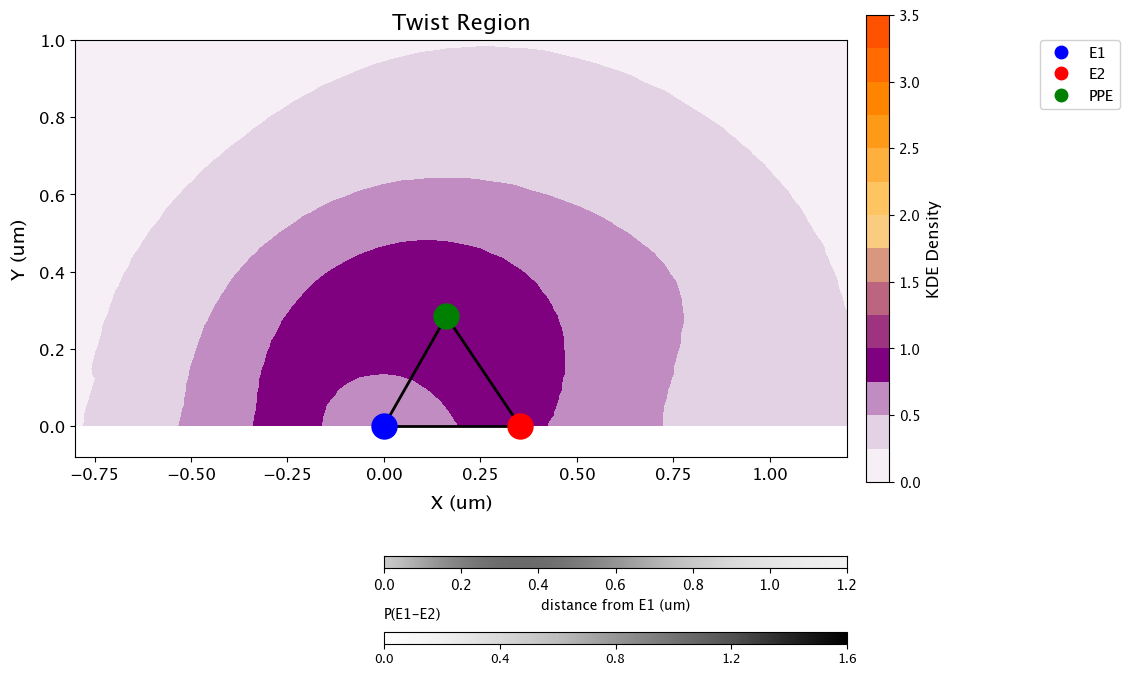

PPE peak: (0.162, 0.284) um


In [32]:
# Compute contour for Twist region (uses DV KDE results)
if 'kde_results_e1_ppe_DV_all' in globals() and 'kde_results_e2_ppe_DV_all' in globals() and 'kde_results_e1_e2_DV_all' in globals():
    Z_twi, X_twi, Y_twi, E1_twi, E2_twi, PPE_twi = plot_contour_stage(
        kde_results_e2_ppe_DV_all['sample_1']['x'], kde_results_e1_ppe_DV_all['sample_1']['x'],
        kde_results_e2_ppe_DV_all['sample_1']['y'], kde_results_e1_ppe_DV_all['sample_1']['y'],
        kde_results_e1_e2_DV_all['sample_1']['x'], kde_results_e1_e2_DV_all['sample_1']['y'],
        title='Twist Region', show_legend=True, num_samples=10, vmin=0, vmax=3.5
    )
    print(f'PPE peak: ({PPE_twi[0]:.3f}, {PPE_twi[1]:.3f}) um')
else:
    print('Missing DV KDE results. Run Section III (Twist vs No-Twist PDFs) first.')


## VII.B: No-Twist Region Contour

Surface integral: 1.0000


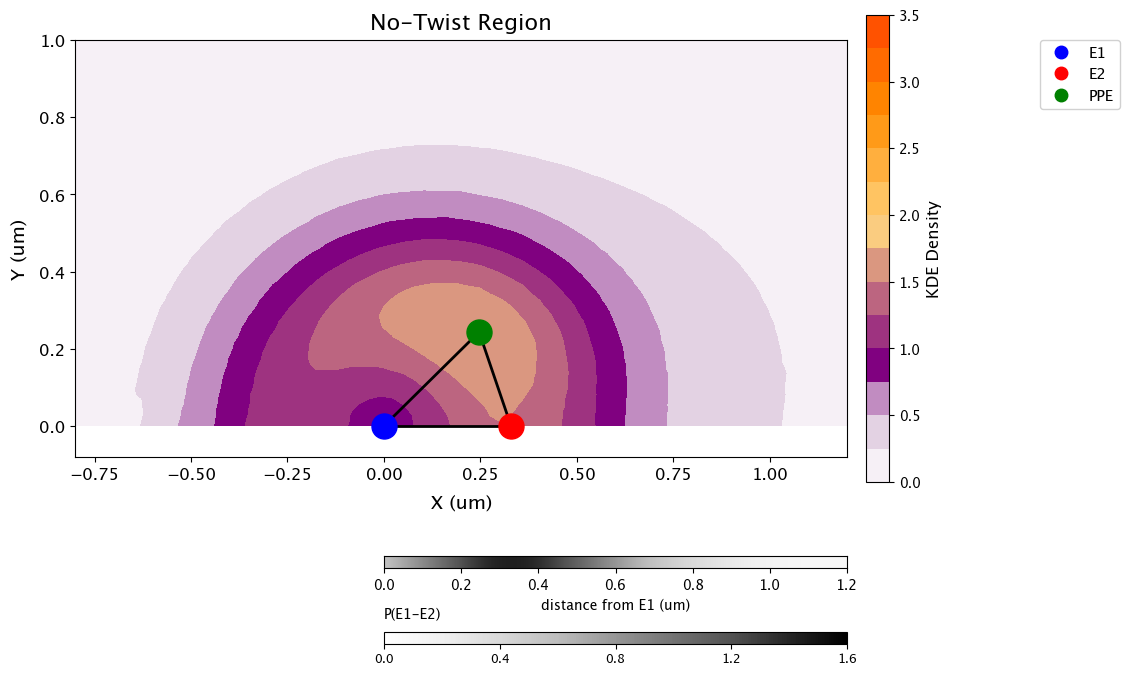

PPE peak: (0.246, 0.243) um


In [33]:
# No-Twist Region contour (uses DV KDE results)
if 'kde_results_e1_ppe_DV_all' in globals() and 'kde_results_e2_ppe_DV_all' in globals() and 'kde_results_e1_e2_DV_all' in globals():
    Z_notwi, X_notwi, Y_notwi, E1_notwi, E2_notwi, PPE_notwi = plot_contour_stage(
        kde_results_e2_ppe_DV_all['sample_2']['x'], kde_results_e1_ppe_DV_all['sample_2']['x'],
        kde_results_e2_ppe_DV_all['sample_2']['y'], kde_results_e1_ppe_DV_all['sample_2']['y'],
        kde_results_e1_e2_DV_all['sample_2']['x'], kde_results_e1_e2_DV_all['sample_2']['y'],
        title='No-Twist Region', show_legend=True, num_samples=10, vmin=0, vmax=3.5
    )
    print(f'PPE peak: ({PPE_notwi[0]:.3f}, {PPE_notwi[1]:.3f}) um')
else:
    print('Missing DV KDE results. Run Section III (Twist vs No-Twist PDFs) first.')


## VII.C: Subtraction Contour (Twist minus No-Twist)

Shows the **difference** in probability density between Twist and No-Twist regions.

**Interpretation:**
- **Red**: PPE is more likely in this position in the Twist region
- **Blue**: PPE is more likely in this position in the No-Twist region
- **White**: No difference

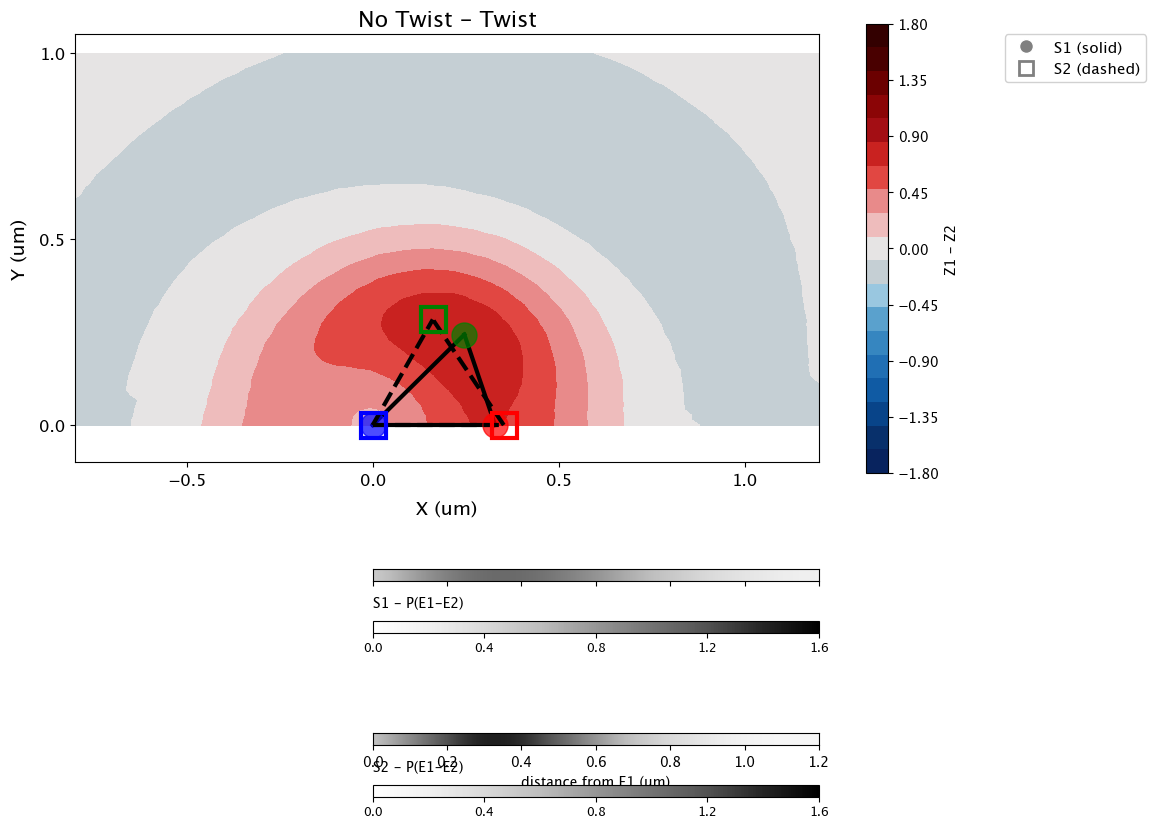

In [34]:
# Subtraction contour: No Twist-Twist (Figure 7G)
if 'Z_twi' in dir() and 'Z_notwi' in dir() and 'kde_results_e1_e2_DV_all' in globals():
    Z_diff_twi_notwi = plot_difference_contour_with_e1e2_pdf(
        Z_notwi, X_notwi, Y_notwi,
        Z_twi, X_twi, Y_twi,
        E1_notwi, E2_notwi, PPE_notwi,
        E1_twi, E2_twi, PPE_twi,
        kde_results_e1_e2_DV_all['sample_1']['x'], kde_results_e1_e2_DV_all['sample_1']['y'],
        kde_results_e1_e2_DV_all['sample_2']['x'], kde_results_e1_e2_DV_all['sample_2']['y'],
        title='No Twist - Twist',
        vmin=-1.8, vmax=1.8
    )
else:
    print('Contour data not available for subtraction plot')


## VII.D: Anterior Region Contour

Contour plot for the pooled Anterior region (all cells anterior of the midpoint).

Surface integral: 1.0000


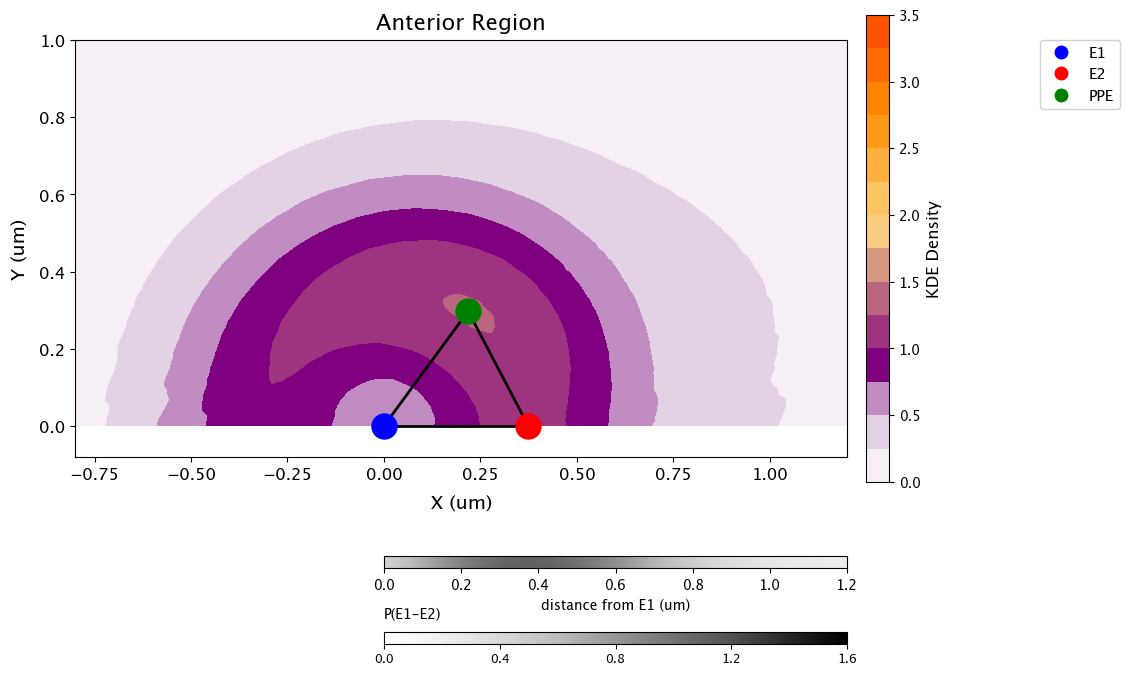

PPE peak: (0.218, 0.297) um


In [35]:
# Anterior Region contour (uses pooled AP KDE results)
if 'kde_results_e1_ppe_AP_all' in globals() and 'kde_results_e2_ppe_AP_all' in globals() and 'kde_results_e1_e2_AP_all' in globals():
    Z_ant, X_ant, Y_ant, E1_ant, E2_ant, PPE_ant = plot_contour_stage(
        kde_results_e2_ppe_AP_all['sample_1']['x'], kde_results_e1_ppe_AP_all['sample_1']['x'],
        kde_results_e2_ppe_AP_all['sample_1']['y'], kde_results_e1_ppe_AP_all['sample_1']['y'],
        kde_results_e1_e2_AP_all['sample_1']['x'], kde_results_e1_e2_AP_all['sample_1']['y'],
        title='Anterior Region', show_legend=True, num_samples=10, vmin=0, vmax=3.5
    )
    print(f'PPE peak: ({PPE_ant[0]:.3f}, {PPE_ant[1]:.3f}) um')
else:
    print('Missing pooled AP KDE results. Run Section VI (Pooled A/P PDFs) first.')


## VII.E: Posterior Region Contour

Surface integral: 1.0000


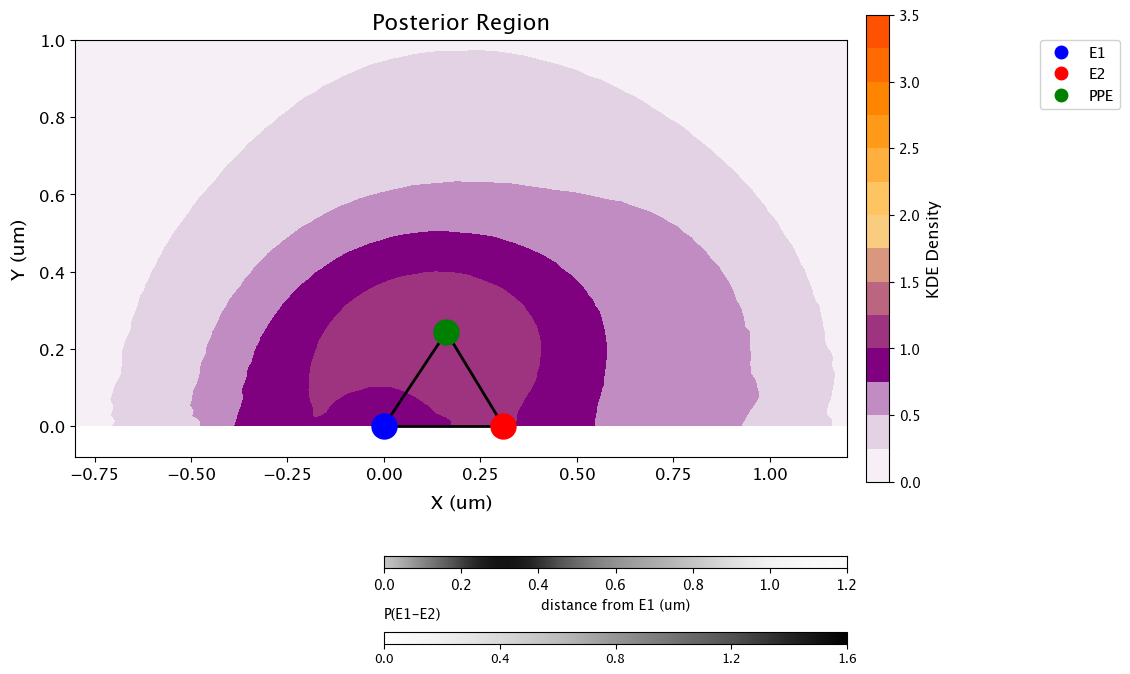

PPE peak: (0.162, 0.243) um


In [36]:
# Posterior Region contour (uses pooled AP KDE results)
if 'kde_results_e1_ppe_AP_all' in globals() and 'kde_results_e2_ppe_AP_all' in globals() and 'kde_results_e1_e2_AP_all' in globals():
    Z_post, X_post, Y_post, E1_post, E2_post, PPE_post = plot_contour_stage(
        kde_results_e2_ppe_AP_all['sample_2']['x'], kde_results_e1_ppe_AP_all['sample_2']['x'],
        kde_results_e2_ppe_AP_all['sample_2']['y'], kde_results_e1_ppe_AP_all['sample_2']['y'],
        kde_results_e1_e2_AP_all['sample_2']['x'], kde_results_e1_e2_AP_all['sample_2']['y'],
        title='Posterior Region', show_legend=True, num_samples=10, vmin=0, vmax=3.5
    )
    print(f'PPE peak: ({PPE_post[0]:.3f}, {PPE_post[1]:.3f}) um')
else:
    print('Missing pooled AP KDE results. Run Section VI (Pooled A/P PDFs) first.')


## VII.F: Subtraction Contour (Anterior minus Posterior)

**Corresponds to Figure 7J in the paper.**

Red = Anterior has higher probability | Blue = Posterior has higher probability

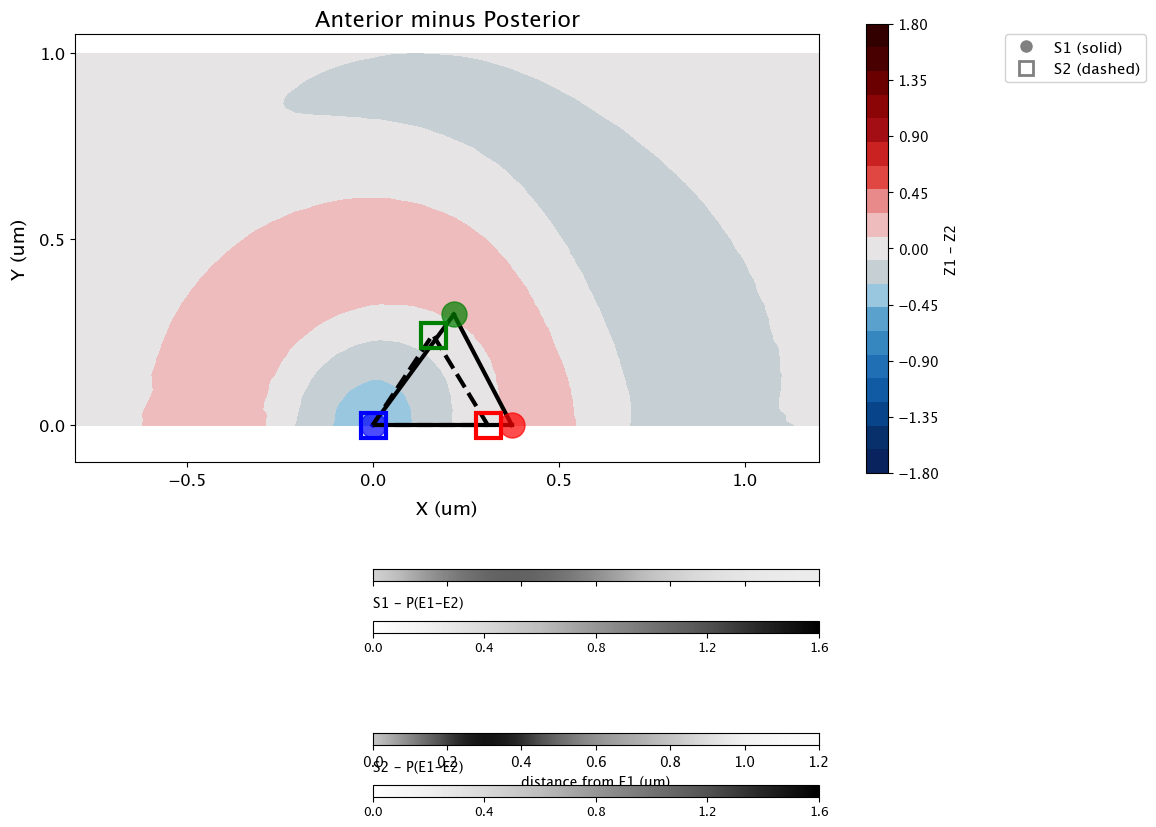

In [37]:
# Subtraction contour: Anterior minus Posterior (Figure 7J)
if 'Z_ant' in dir() and 'Z_post' in dir() and 'kde_results_e1_e2_AP_all' in globals():
    Z_diff_ap = plot_difference_contour_with_e1e2_pdf(
        Z_ant, X_ant, Y_ant,
        Z_post, X_post, Y_post,
        E1_ant, E2_ant, PPE_ant,
        E1_post, E2_post, PPE_post,
        kde_results_e1_e2_AP_all['sample_1']['x'], kde_results_e1_e2_AP_all['sample_1']['y'],
        kde_results_e1_e2_AP_all['sample_2']['x'], kde_results_e1_e2_AP_all['sample_2']['y'],
        title='Anterior minus Posterior',
        vmin=-1.8, vmax=1.8
    )
else:
    print('Contour data not available for A-P subtraction plot')


---

<a id="section-viii"></a>
# Section VIII: Cross-Region Heatmaps

P-value heatmaps comparing all four embryo regions pairwise.

These heatmaps allow comparison of:
- Twist vs No-Twist at each A-P position
- Anterior vs Posterior at each D-V position

## VIII.A: E1-PPE All-Region Heatmap

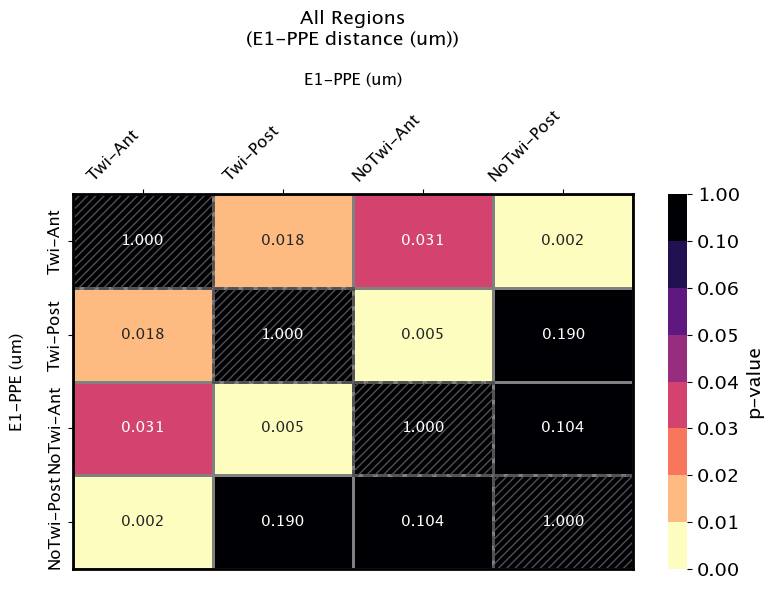

In [38]:
# Collect all available E1-PPE DataFrames
all_e1_ppe_dfs = []
all_e1_ppe_labels = []

for df, label in [
    (twi_A_E1_PPE, 'Twi-Ant'),
    (twi_C_E1_PPE, 'Twi-Post'),
    (no_twi_A_E1_PPE, 'NoTwi-Ant'),
    (no_twi_C_E1_PPE, 'NoTwi-Post')
]:
    if not df.empty:
        all_e1_ppe_dfs.append(df)
        all_e1_ppe_labels.append(label)

if len(all_e1_ppe_dfs) >= 2:
    generate_pvalue_heatmap(
        dataframes_1=all_e1_ppe_dfs,
        dataframes_2=all_e1_ppe_dfs,
        labels_1=all_e1_ppe_labels,
        labels_2=all_e1_ppe_labels,
        distance_column='E1-PPE distance (um)',
        title='All Regions',
        x_axis_label='E1-PPE (um)',
        y_axis_label='E1-PPE (um)'
    )

## VIII.B: E2-PPE All-Region Heatmap

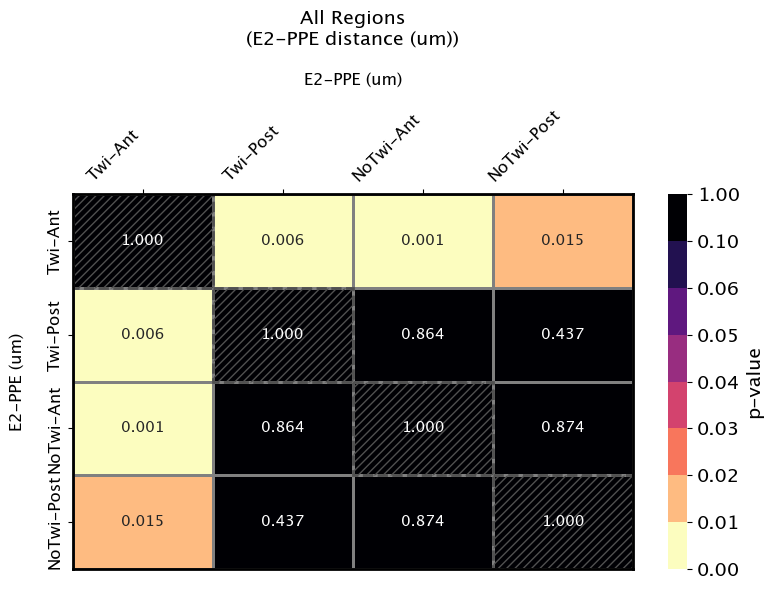

In [39]:
all_e2_ppe_dfs = []
all_e2_ppe_labels = []

for df, label in [
    (twi_A_E2_PPE, 'Twi-Ant'),
    (twi_C_E2_PPE, 'Twi-Post'),
    (no_twi_A_E2_PPE, 'NoTwi-Ant'),
    (no_twi_C_E2_PPE, 'NoTwi-Post')
]:
    if not df.empty:
        all_e2_ppe_dfs.append(df)
        all_e2_ppe_labels.append(label)

if len(all_e2_ppe_dfs) >= 2:
    generate_pvalue_heatmap(
        dataframes_1=all_e2_ppe_dfs,
        dataframes_2=all_e2_ppe_dfs,
        labels_1=all_e2_ppe_labels,
        labels_2=all_e2_ppe_labels,
        distance_column='E2-PPE distance (um)',
        title='All Regions',
        x_axis_label='E2-PPE (um)',
        y_axis_label='E2-PPE (um)'
    )

## VIII.C: E1-E2 All-Region Heatmap

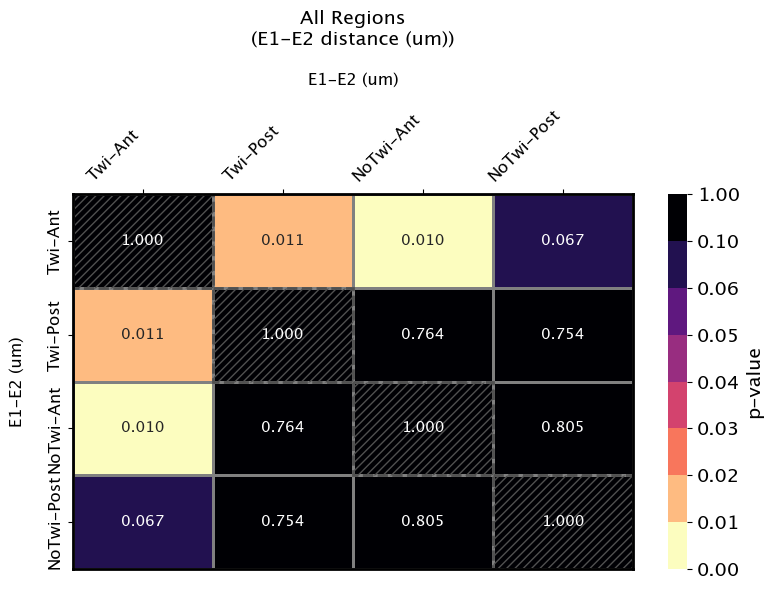

In [40]:
all_e1_e2_dfs = []
all_e1_e2_labels = []

for df, label in [
    (twi_A_E1_E2, 'Twi-Ant'),
    (twi_C_E1_E2, 'Twi-Post'),
    (no_twi_A_E1_E2, 'NoTwi-Ant'),
    (no_twi_C_E1_E2, 'NoTwi-Post')
]:
    if not df.empty:
        all_e1_e2_dfs.append(df)
        all_e1_e2_labels.append(label)

if len(all_e1_e2_dfs) >= 2:
    generate_pvalue_heatmap(
        dataframes_1=all_e1_e2_dfs,
        dataframes_2=all_e1_e2_dfs,
        labels_1=all_e1_e2_labels,
        labels_2=all_e1_e2_labels,
        distance_column='E1-E2 distance (um)',
        title='All Regions',
        x_axis_label='E1-E2 (um)',
        y_axis_label='E1-E2 (um)'
    )

---

<a id="section-ix"></a>
# Section IX: Summary

## Analyses Performed

| Analysis | Description | Section |
|----------|-------------|--------|
| **Twist vs No-Twist PDFs** | D-V axis comparison of all 3 distance types | III |
| **A/P within Twist** | Anterior vs Posterior in ventral domain | IV |
| **A/P within No-Twist** | Anterior vs Posterior in dorsal domain | V |
| **Pooled A/P** | All anterior vs all posterior | VI |
| **Contour plots** | 2D joint probability distributions | VII |
| **Subtraction contour** | Twist minus No-Twist density difference | VII |
| **All-region heatmaps** | Pairwise p-values across 4 quadrants | VIII |

## Variables Created

### Twist Region
```
twi_E1_PPE, twi_E2_PPE, twi_E1_E2
twi_A_E1_PPE, twi_A_E2_PPE, twi_A_E1_E2  (Anterior)
twi_C_E1_PPE, twi_C_E2_PPE, twi_C_E1_E2  (Posterior)
```

### No-Twist Region
```
no_twi_E1_PPE, no_twi_E2_PPE, no_twi_E1_E2
no_twi_A_E1_PPE, no_twi_A_E2_PPE, no_twi_A_E1_E2  (Anterior)
no_twi_C_E1_PPE, no_twi_C_E2_PPE, no_twi_C_E1_E2  (Posterior)
```

### Pooled
```
ant_E1_PPE, ant_E2_PPE, ant_E1_E2  (All anterior)
post_E1_PPE, post_E2_PPE, post_E1_E2  (All posterior)
```

## Output Files

| File | Description |
|------|-------------|
| `twi_not_twi_distance_data.xlsx` | Twist vs No-Twist distance data |

In [41]:
# =============================================================================
# SAMPLE SIZE SUMMARY
# =============================================================================
print("=" * 60)
print("SAMPLE SIZE SUMMARY")
print("=" * 60)

print("\nOverall D-V Comparison:")
print(f"  Twist:    E1-PPE={len(twi_E1_PPE)}, E2-PPE={len(twi_E2_PPE)}, E1-E2={len(twi_E1_E2)}")
print(f"  No-Twist: E1-PPE={len(no_twi_E1_PPE)}, E2-PPE={len(no_twi_E2_PPE)}, E1-E2={len(no_twi_E1_E2)}")

print("\nA/P Within Twist Region:")
print(f"  Anterior:  E1-PPE={len(twi_A_E1_PPE)}, E2-PPE={len(twi_A_E2_PPE)}, E1-E2={len(twi_A_E1_E2)}")
print(f"  Posterior: E1-PPE={len(twi_C_E1_PPE)}, E2-PPE={len(twi_C_E2_PPE)}, E1-E2={len(twi_C_E1_E2)}")

print("\nA/P Within No-Twist Region:")
print(f"  Anterior:  E1-PPE={len(no_twi_A_E1_PPE)}, E2-PPE={len(no_twi_A_E2_PPE)}, E1-E2={len(no_twi_A_E1_E2)}")
print(f"  Posterior: E1-PPE={len(no_twi_C_E1_PPE)}, E2-PPE={len(no_twi_C_E2_PPE)}, E1-E2={len(no_twi_C_E1_E2)}")

print("\nPooled A/P:")
print(f"  Anterior:  E1-PPE={len(ant_E1_PPE)}, E2-PPE={len(ant_E2_PPE)}, E1-E2={len(ant_E1_E2)}")
print(f"  Posterior: E1-PPE={len(post_E1_PPE)}, E2-PPE={len(post_E2_PPE)}, E1-E2={len(post_E1_E2)}")

print("\n" + "=" * 60)
print("Figure 7 analysis complete!")
print("For Figures 3-6, see: Figure3-6_distances_cleaned.ipynb")
print("=" * 60)

SAMPLE SIZE SUMMARY

Overall D-V Comparison:
  Twist:    E1-PPE=352, E2-PPE=94, E1-E2=96
  No-Twist: E1-PPE=447, E2-PPE=107, E1-E2=110

A/P Within Twist Region:
  Anterior:  E1-PPE=124, E2-PPE=26, E1-E2=40
  Posterior: E1-PPE=169, E2-PPE=47, E1-E2=46

A/P Within No-Twist Region:
  Anterior:  E1-PPE=158, E2-PPE=35, E1-E2=34
  Posterior: E1-PPE=141, E2-PPE=35, E1-E2=48

Pooled A/P:
  Anterior:  E1-PPE=282, E2-PPE=61, E1-E2=74
  Posterior: E1-PPE=310, E2-PPE=82, E1-E2=94

Figure 7 analysis complete!
For Figures 3-6, see: Figure3-6_distances_cleaned.ipynb
